<a href="https://colab.research.google.com/github/jonitodev/PembelajaranMesin/blob/main/JS04/JS04_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS04 — Tugas Lab

Data: `insurance.csv`. Unggah ke Files di Colab, lalu jalankan semua sel.

[Jobsheet Tugas Lab](https://polinema.gitbook.io/jti-modul-praktikum-pembelajaran-mesin-mah/js04-regresi/tugas-lab)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
DATA_DIR = Path('/content') if Path('/content').is_dir() else Path('.')

def evaluasi(aktual, prediksi):
    mse = mean_squared_error(aktual, prediksi)
    return {'R2': r2_score(aktual, prediksi), 'MSE': mse,
            'MAE': mean_absolute_error(aktual, prediksi), 'RMSE': np.sqrt(mse)}

## Tugas Lab — Biaya medis

Targetnya `charges` (biaya medis). Fiturnya adalah `age` (usia), `bmi` (indeks massa
tubuh), `children` (jumlah tanggungan), `sex` (jenis kelamin), `smoker` (status merokok),
dan `region` (wilayah tempat tinggal).

In [2]:
data = pd.read_csv(DATA_DIR / 'insurance.csv')
display(data.head())
print('Ukuran data:', data.shape)
print('Nilai kosong:', data.isna().sum().sum())
print('Duplikat:', data.duplicated().sum())
data = data.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


Ukuran data: (1338, 7)
Nilai kosong: 0
Duplikat: 1


Satu baris duplikat dihapus sebelum pembagian data. Train dan test dibagi 80:20 dengan proporsi perokok yang seimbang.

Train: 1069, test: 268


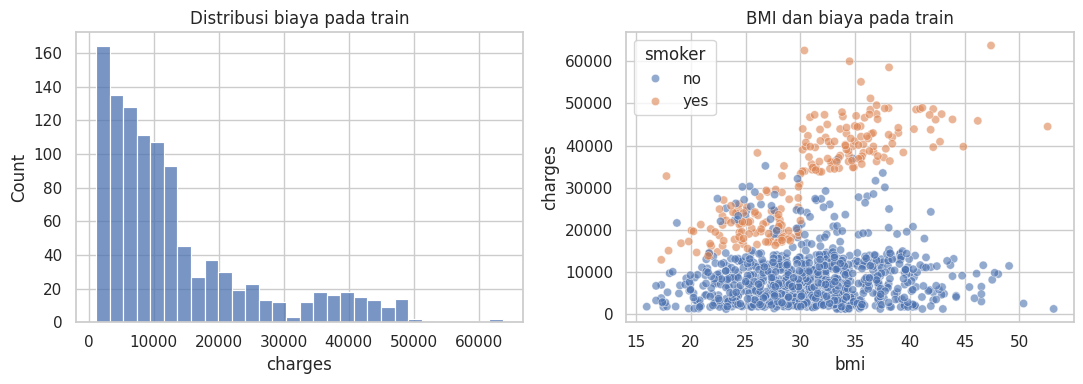

In [3]:
numerik = ['age', 'bmi', 'children']
kategori = ['sex', 'smoker', 'region']
X = data[numerik + kategori]
y = data['charges']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X['smoker'])
print(f'Train: {len(X_train)}, test: {len(X_test)}')

data_train = X_train.join(y_train)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data_train, x='charges', bins=30, ax=axes[0])
sns.scatterplot(data_train, x='bmi', y='charges', hue='smoker', alpha=0.6, ax=axes[1])
axes[0].set_title('Distribusi biaya pada train')
axes[1].set_title('BMI dan biaya pada train')
plt.tight_layout()
plt.show()

### Regresi linier berganda
Kategori diubah menjadi one-hot encoding. Fitur numerik tetap dalam satuan aslinya.

In [4]:
preprocess_lr = ColumnTransformer([
    ('num', 'passthrough', numerik),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), kategori)
])
model_lr = Pipeline([('preprocess', preprocess_lr), ('model', LinearRegression())])
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
display(pd.Series(evaluasi(y_test, pred_lr), name='Regresi linier'))

,Regresi linier
R2,0.8205
MSE,"25,876,347.3211"
MAE,"3,592.7926"
RMSE,"5,086.8799"


### SVR

Fitur numerik dan target distandarkan. Parameter SVR dicari dengan 5-fold
cross validation pada train. Prediksi dikembalikan ke satuan biaya asli.

In [5]:
preprocess_svr = ColumnTransformer([
    ('num', StandardScaler(), numerik),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), kategori)
])
model_svr = TransformedTargetRegressor(
    regressor=Pipeline([('preprocess', preprocess_svr), ('svr', SVR(kernel='rbf'))]),
    transformer=StandardScaler()
)
parameter = {
    'regressor__svr__C': [1, 10, 100],
    'regressor__svr__epsilon': [0.05, 0.1, 0.2],
    'regressor__svr__gamma': ['scale', 0.01, 0.1, 1]
}
grid_svr = GridSearchCV(model_svr, parameter, scoring='neg_root_mean_squared_error',
                       cv=KFold(5, shuffle=True, random_state=42), n_jobs=1)
grid_svr.fit(X_train, y_train)
pred_svr = grid_svr.predict(X_test)
print('Parameter terbaik:', {k.split('__')[-1]: v for k, v in grid_svr.best_params_.items()})
print(f'RMSE validasi: {-grid_svr.best_score_:,.2f}')

Parameter terbaik: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01}
RMSE validasi: 4,972.90


### Hasil evaluasi
Kedua model diuji pada data yang sama. Error lebih kecil dan R² lebih besar menunjukkan hasil yang lebih baik; R² juga bisa bernilai negatif.

,R2,MSE,MAE,RMSE
Regresi linier,0.8205,"25,876,347.3211","3,592.7926","5,086.8799"
SVR,0.9061,"13,536,654.6175","2,166.5166","3,679.2193"


,Aktual,Regresi linier,SVR
575,"12,222.8983","11,877.3768","12,969.8965"
932,"10,096.9700","10,555.1200","9,935.1100"
956,"41,999.5200","35,340.2627","35,396.9321"
144,"20,745.9891","30,584.8084","26,494.1987"
684,"4,766.0220","2,566.4434","5,888.7736"
633,"7,173.3600","7,149.0630","8,175.0133"
614,"1,880.0700","3,248.4288","3,046.7001"
1101,"11,253.4210","12,020.6567","12,012.8026"
702,"9,504.3103","14,238.1456","10,308.3910"
969,"8,596.8278","11,678.3788","9,853.5768"


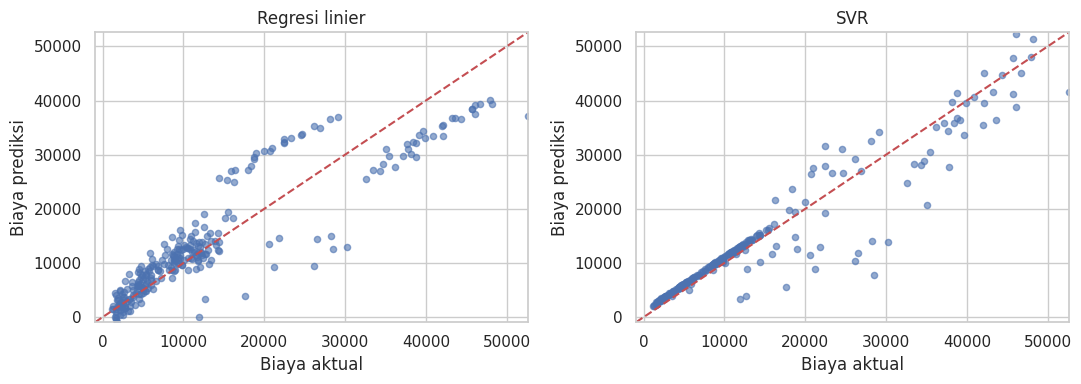

In [6]:
hasil = pd.DataFrame({'Regresi linier': evaluasi(y_test, pred_lr),
                      'SVR': evaluasi(y_test, pred_svr)}).T
display(hasil)
display(pd.DataFrame({'Aktual': y_test, 'Regresi linier': pred_lr, 'SVR': pred_svr}).head(10))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
batas = [min(0, pred_lr.min(), pred_svr.min()), max(y_test.max(), pred_lr.max(), pred_svr.max())]
for ax, pred, nama in [(axes[0], pred_lr, 'Regresi linier'), (axes[1], pred_svr, 'SVR')]:
    ax.scatter(y_test, pred, alpha=0.6, s=20)
    ax.plot(batas, batas, 'r--')
    ax.set(title=nama, xlabel='Biaya aktual', ylabel='Biaya prediksi', xlim=batas, ylim=batas)
plt.tight_layout()
plt.show()

### Kesimpulan

Pada pembagian ini, SVR menghasilkan R² 0,9061 dan RMSE 3.679,22, lebih baik
daripada regresi linier dengan R² 0,8205 dan RMSE 5.086,88. SVR dapat mengikuti
pola nonlinier pada data biaya medis. Hasil ini berlaku untuk dataset dan
pembagian yang digunakan; beberapa prediksi regresi linier masih bernilai negatif.